# IZI Health Diabetes Prediction


## features

1. `gender`
2. `age`
3. `hypertension`
4. `heart_disease`
5. `smoking_history`
6. `bmi`
7. `HbA1c_level`
8. `blood_glucose_level`

## Notebook objectives

- Data quality and analytics
- Class-distribution pie chart
- Numerical histograms
- Correlation heatmap
- Multiple-model comparison
- Hyperparameter tuning
- Confusion matrix
- Accuracy, precision, recall, F1 and ROC-AUC
- ROC and precision-recall curves
- Feature importance
- Prediction-confidence analysis
- Response-time testing

## 1. Install and import libraries

In [1]:
%pip install -q --upgrade \
    "numpy==1.26.4" \
    "scipy==1.13.1" \
    "pandas==2.2.2" \
    "scikit-learn==1.5.2" \
    "matplotlib==3.9.2" \
    "seaborn==0.13.2" \
    "joblib==1.4.2"

In [2]:
# IZI Health Diabetes Prediction — Imports and Configuration

import os
import json
import time
import shutil
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Output directories
OUTPUT_DIR = Path("/content/izi_diabetes_outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Plot configuration
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn imported successfully.")
print("Seaborn:", sns.__version__)
print("Output directory:", OUTPUT_DIR)

All libraries imported successfully.
NumPy: 1.26.4
Pandas: 2.2.2
Scikit-learn imported successfully.
Seaborn: 0.13.2
Output directory: /content/izi_diabetes_outputs


# Dataset preparation

## 2. Upload the diabetes datasets

In [3]:
uploaded = files.upload()
if not uploaded:
    raise ValueError("No file uploaded.")

uploaded_name = next(iter(uploaded))
uploaded_path = Path("/content") / uploaded_name
EXTRACT_DIR = Path("/content/uploaded_diabetes_service")
EXTRACT_DIR.mkdir(exist_ok=True)

if uploaded_path.suffix.lower() == ".zip":
    with zipfile.ZipFile(uploaded_path, "r") as archive:
        archive.extractall(EXTRACT_DIR)
    candidates = list(EXTRACT_DIR.rglob("diabetes_prediction_dataset.csv"))
else:
    candidates = [uploaded_path]

if not candidates:
    raise FileNotFoundError("diabetes_prediction_dataset.csv was not found.")

DATA_PATH = candidates[0]
print("Dataset selected:", DATA_PATH)

Saving diabetes_prediction_dataset.csv.zip to diabetes_prediction_dataset.csv.zip
Dataset selected: /content/uploaded_diabetes_service/diabetes_prediction_dataset.csv


## 3. Load and inspect the dataset

The inspection checks dimensions, column names, data types, missing values and duplicate records.

In [4]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Shape: (100000, 9)
Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:
quality = pd.DataFrame({
    "Data type": df.dtypes.astype(str),
    "Missing values": df.isna().sum(),
    "Unique values": df.nunique()
})
display(quality)
print("Duplicate rows:", df.duplicated().sum())

,Data type,Missing values,Unique values
gender,object,0,3
age,float64,0,102
hypertension,int64,0,2
heart_disease,int64,0,2
smoking_history,object,0,6
bmi,float64,0,4247
HbA1c_level,float64,0,18
blood_glucose_level,int64,0,18
diabetes,int64,0,2


Duplicate rows: 3854


## 4. Validate the deployment schema

In [6]:
TARGET = "diabetes"
CATEGORICAL_FEATURES = ["gender", "smoking_history"]
NUMERIC_FEATURES = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]
FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

required = FEATURES + [TARGET]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[required].copy()
print("Deployment feature schema confirmed.")

Deployment feature schema confirmed.


# Exploratory data analysis

## 5. Dataset analytics summary

In [7]:
summary = pd.DataFrame({
    "Metric": [
        "Records",
        "Features",
        "Diabetic records",
        "Non-diabetic records",
        "Diabetes prevalence (%)",
        "Duplicate records",
        "Missing values"
    ],
    "Value": [
        len(df),
        len(FEATURES),
        int((df[TARGET] == 1).sum()),
        int((df[TARGET] == 0).sum()),
        round(df[TARGET].mean() * 100, 2),
        int(df.duplicated().sum()),
        int(df.isna().sum().sum())
    ]
})
display(summary)
summary.to_csv(OUTPUT_DIR / "diabetes_dataset_summary.csv", index=False)

,Metric,Value
0,Records,100000.0
1,Features,8.0
2,Diabetic records,8500.0
3,Non-diabetic records,91500.0
4,Diabetes prevalence (%),8.5
5,Duplicate records,3854.0
6,Missing values,0.0


## 6. Diabetes class-distribution pie chart

This dataset is imbalanced. Approximately 8.5% of records are diabetic.

Accuracy alone is therefore insufficient. Recall, F1-score, ROC-AUC and average precision are also required.

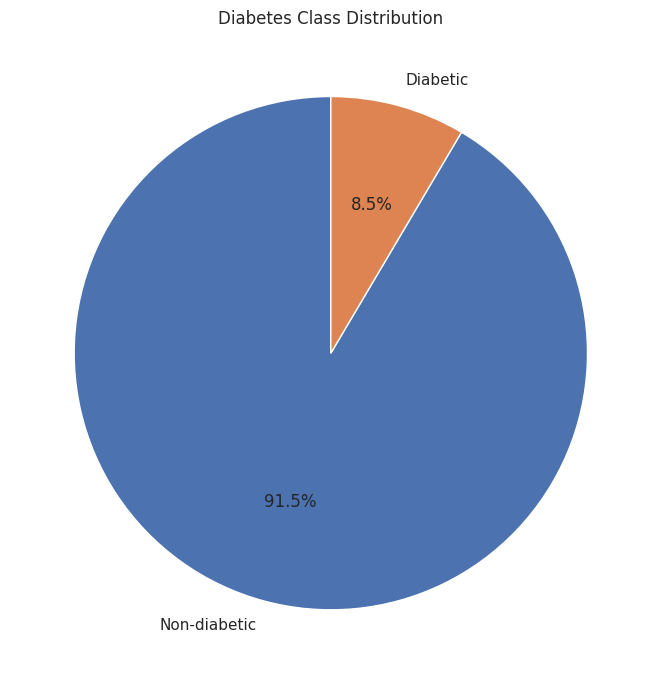

In [8]:
class_counts = df[TARGET].value_counts().sort_index()
labels = ["Non-diabetic", "Diabetic"]

plt.figure(figsize=(8, 7))
plt.pie(
    class_counts.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Diabetes Class Distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "diabetes_class_distribution_pie.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Numerical feature histograms

Histograms show the distribution, concentration and possible skewness of each numerical feature.

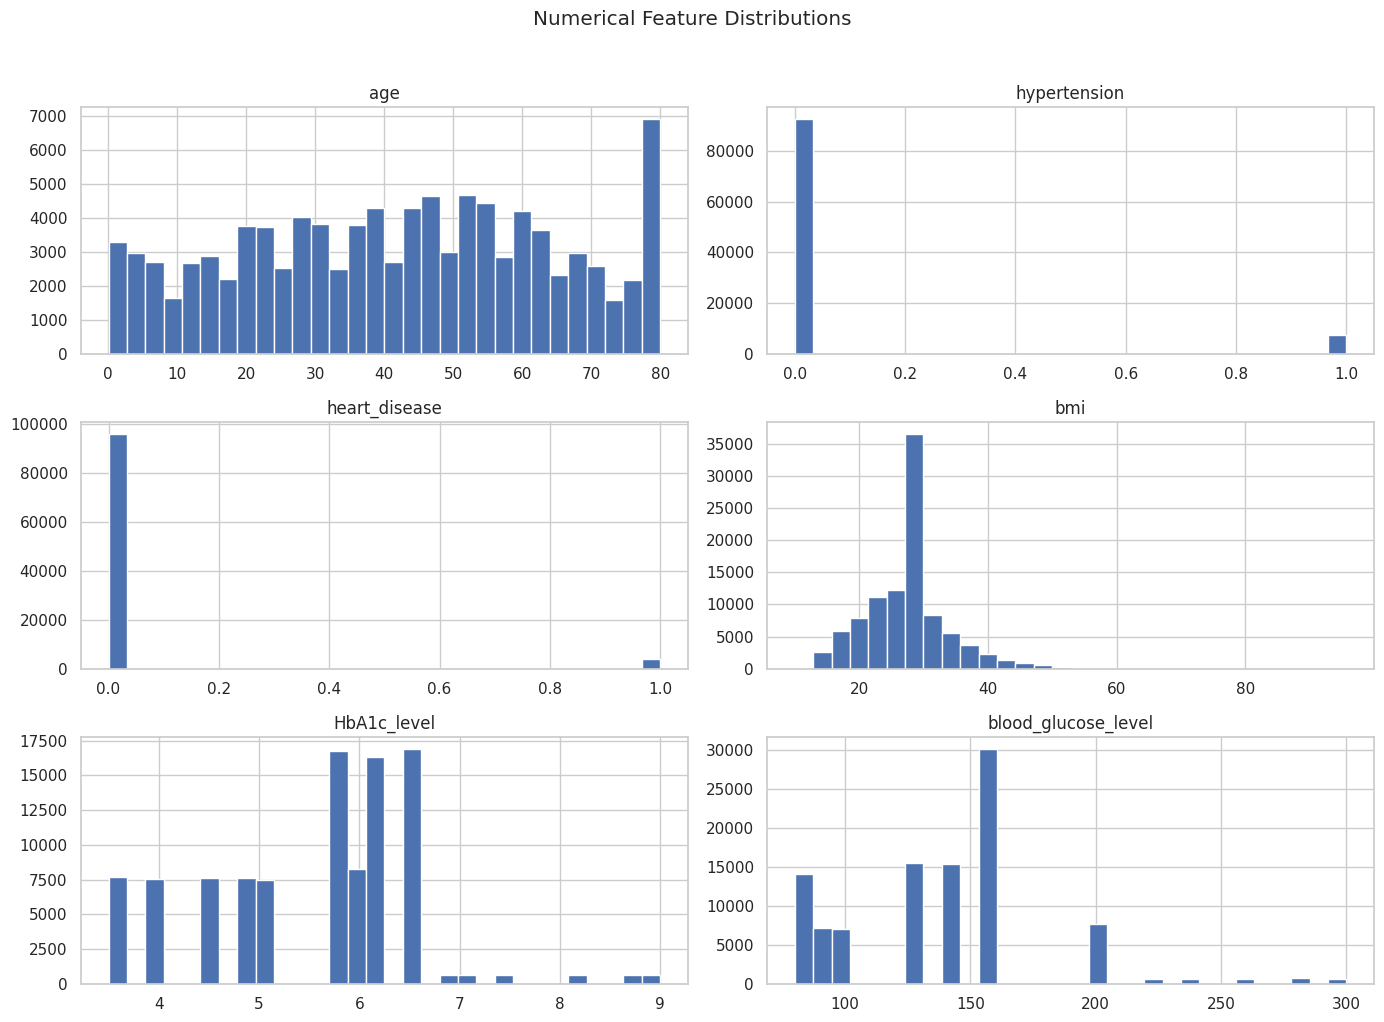

In [9]:
df[NUMERIC_FEATURES].hist(figsize=(14, 10), bins=30)
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "numerical_feature_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Diabetes prevalence by gender

,gender,count,mean,Diabetes prevalence (%)
0,Female,58552,0.076189,7.618869
1,Male,41430,0.097490,9.748974
2,Other,18,0.000000,0.000000


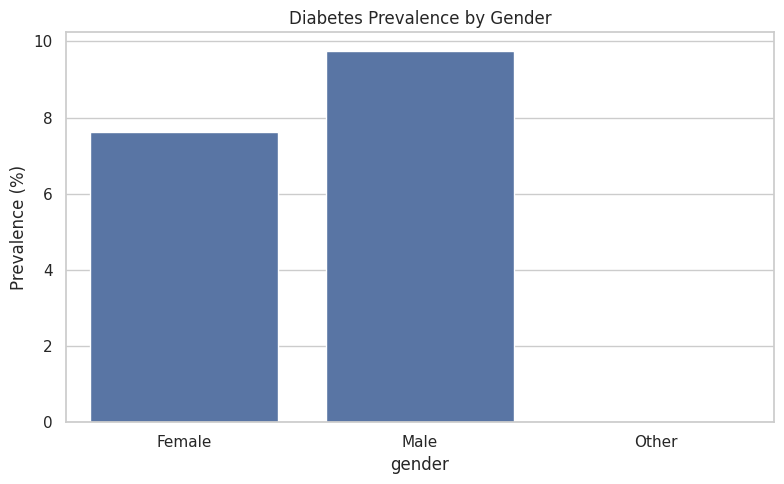

In [10]:
gender_prevalence = (
    df.groupby("gender")[TARGET]
    .agg(["count", "mean"])
    .reset_index()
)
gender_prevalence["Diabetes prevalence (%)"] = gender_prevalence["mean"] * 100
display(gender_prevalence)

plt.figure(figsize=(8, 5))
sns.barplot(data=gender_prevalence, x="gender", y="Diabetes prevalence (%)")
plt.title("Diabetes Prevalence by Gender")
plt.ylabel("Prevalence (%)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "diabetes_prevalence_by_gender.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Smoking-history distribution

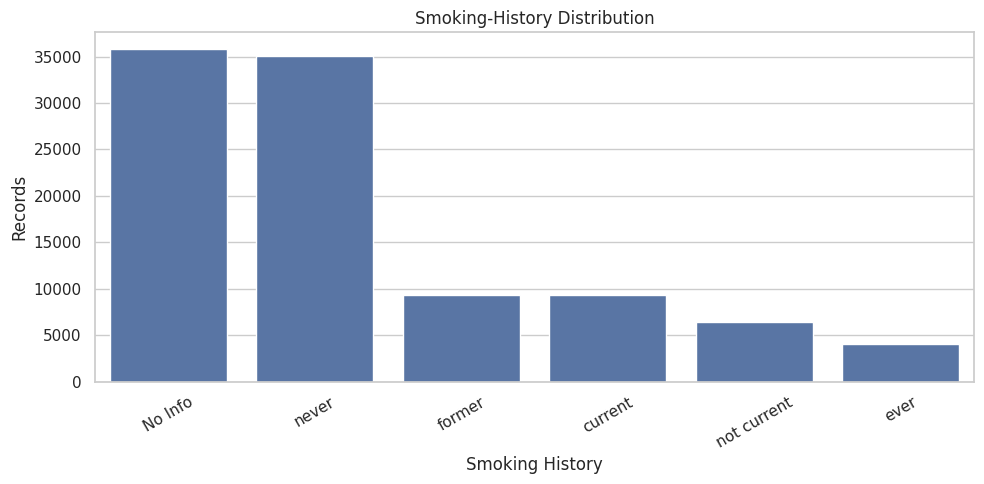

In [11]:
smoking_counts = df["smoking_history"].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=smoking_counts.index, y=smoking_counts.values)
plt.title("Smoking-History Distribution")
plt.xlabel("Smoking History")
plt.ylabel("Records")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "smoking_history_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Correlation heatmap

The heatmap describes linear relationships among numerical features and the diabetes label.

Correlation does not prove causation. It only shows statistical association in this dataset.

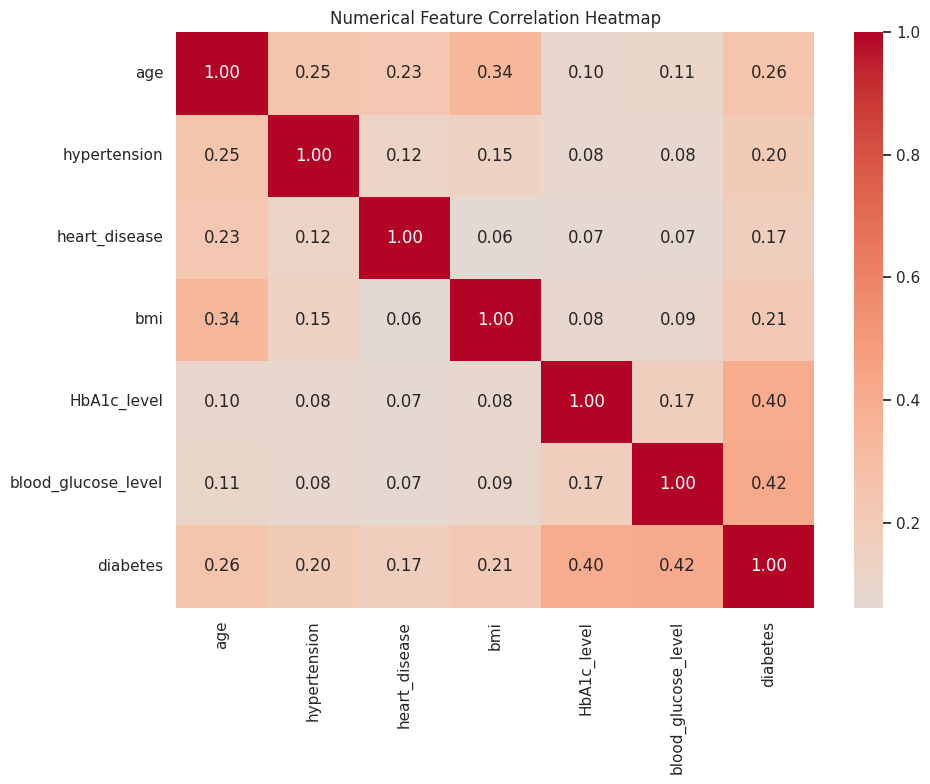

In [12]:
correlation_data = df[NUMERIC_FEATURES + [TARGET]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_data, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numerical Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Clinical feature distributions by diabetes status

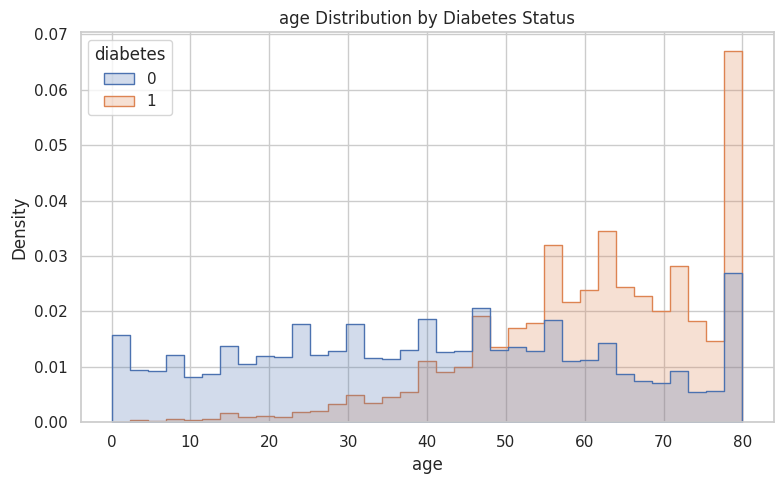

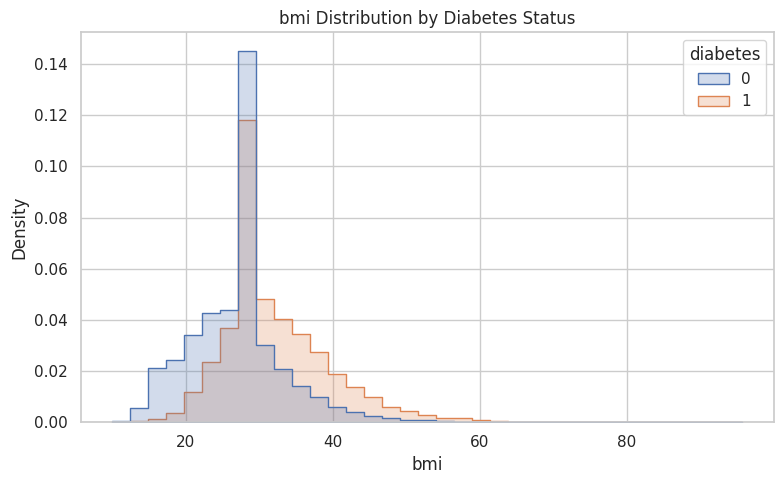

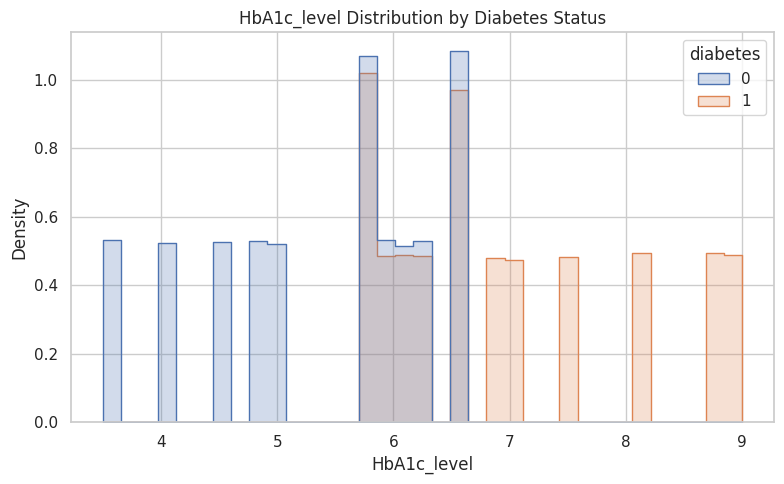

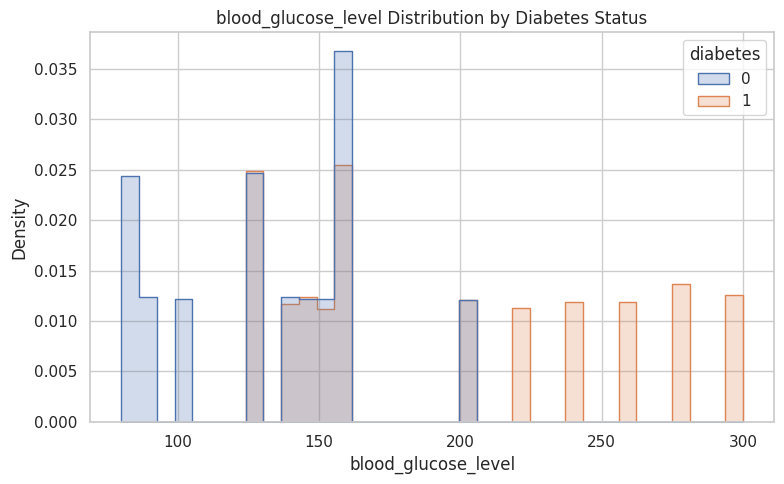

In [13]:
for column in ["age", "bmi", "HbA1c_level", "blood_glucose_level"]:
    plt.figure(figsize=(8, 5))
    sns.histplot(
        data=df,
        x=column,
        hue=TARGET,
        bins=35,
        element="step",
        stat="density",
        common_norm=False
    )
    plt.title(f"{column} Distribution by Diabetes Status")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{column}_by_diabetes.png", dpi=300, bbox_inches="tight")
    plt.show()

# Train, validation and test split

## 12. Split the data

- 70% training
- 15% validation
- 15% testing

Stratification preserves the diabetes prevalence in each split.

In [14]:
X = df[FEATURES].copy()
y = df[TARGET].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

split_summary = pd.DataFrame({
    "Split": ["Training", "Validation", "Testing"],
    "Records": [len(X_train), len(X_val), len(X_test)],
    "Positive rate": [y_train.mean(), y_val.mean(), y_test.mean()]
})
display(split_summary)

,Split,Records,Positive rate
0,Training,70000,0.085
1,Validation,15000,0.085
2,Testing,15000,0.085


# Preprocessing pipeline

## 13. Define preprocessing

Categorical variables are one-hot encoded. Numerical values are median-imputed and passed through without scaling for tree models.

Logistic regression uses a separate scaled numeric pipeline.

In [15]:
tree_preprocessor = ColumnTransformer([
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        CATEGORICAL_FEATURES
    ),
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]),
        NUMERIC_FEATURES
    )
])

linear_preprocessor = ColumnTransformer([
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        CATEGORICAL_FEATURES
    ),
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        NUMERIC_FEATURES
    )
])

# Baseline and candidate models

## 14. Hyperparameter table

`class_weight="balanced"` is considered because the positive class is much smaller.

In [16]:
hyperparameters = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Hyperparameters": "C=1.0, max_iter=1000, class_weight='balanced'",
        "Role": "Interpretable linear baseline"
    },
    {
        "Model": "Decision Tree",
        "Hyperparameters": "max_depth=8, min_samples_leaf=20, class_weight='balanced'",
        "Role": "Simple nonlinear baseline"
    },
    {
        "Model": "Random Forest",
        "Hyperparameters": "n_estimators=120, random_state=42, class_weight='balanced'",
        "Role": "Current production family"
    },
    {
        "Model": "Gradient Boosting",
        "Hyperparameters": "n_estimators=120, learning_rate=0.05, max_depth=3",
        "Role": "Boosted-tree comparison"
    },
    {
        "Model": "Extra Trees",
        "Hyperparameters": "n_estimators=200, class_weight='balanced'",
        "Role": "Randomized-tree comparison"
    }
])
display(hyperparameters)
hyperparameters.to_csv(OUTPUT_DIR / "diabetes_hyperparameters.csv", index=False)

,Model,Hyperparameters,Role
0,Logistic Regression,"C=1.0, max_iter=1000, class_weight='balanced'",Interpretable linear baseline
1,Decision Tree,"max_depth=8, min_samples_leaf=20, class_weight...",Simple nonlinear baseline
2,Random Forest,"n_estimators=120, random_state=42, class_weigh...",Current production family
3,Gradient Boosting,"n_estimators=120, learning_rate=0.05, max_depth=3",Boosted-tree comparison
4,Extra Trees,"n_estimators=200, class_weight='balanced'",Randomized-tree comparison


In [17]:
candidate_models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", linear_preprocessor),
        ("classifier", LogisticRegression(
            C=1.0,
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED
        ))
    ]),
    "Decision Tree": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=SEED
        ))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=120,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=120,
            learning_rate=0.05,
            max_depth=3,
            random_state=SEED
        ))
    ]),
    "Extra Trees": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("classifier", ExtraTreesClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        ))
    ])
}

## 15. Train and compare candidate models

The validation set is used for model selection. The test set remains untouched until the final model has been selected and tuned.

In [18]:
comparison_rows = []
trained_models = {}

for name, model in candidate_models.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    training_seconds = time.perf_counter() - start

    prediction = model.predict(X_val)
    probability = model.predict_proba(X_val)[:, 1]

    comparison_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, prediction),
        "Precision": precision_score(y_val, prediction, zero_division=0),
        "Recall": recall_score(y_val, prediction, zero_division=0),
        "F1-score": f1_score(y_val, prediction, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, probability),
        "Average Precision": average_precision_score(y_val, probability),
        "Training Time (s)": training_seconds
    })
    trained_models[name] = model

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ["F1-score", "ROC-AUC"],
    ascending=False
)
display(comparison_df.round(4))
comparison_df.to_csv(OUTPUT_DIR / "diabetes_model_comparison.csv", index=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Average Precision,Training Time (s)
3,Gradient Boosting,0.9732,0.9943,0.6886,0.8137,0.9792,0.8873,8.2087
2,Random Forest,0.9704,0.9324,0.7027,0.8014,0.9658,0.8633,4.4502
4,Extra Trees,0.9671,0.8981,0.6910,0.7810,0.9557,0.8275,7.7045
0,Logistic Regression,0.8893,0.4271,0.8863,0.5764,0.9640,0.8231,0.2059
1,Decision Tree,0.8775,0.4046,0.9349,0.5648,0.9762,0.8616,0.2485


## 16. Model-performance comparison graph

Accuracy, F1 and ROC-AUC are shown together. F1 is especially important because it balances precision and recall for the minority diabetic class.

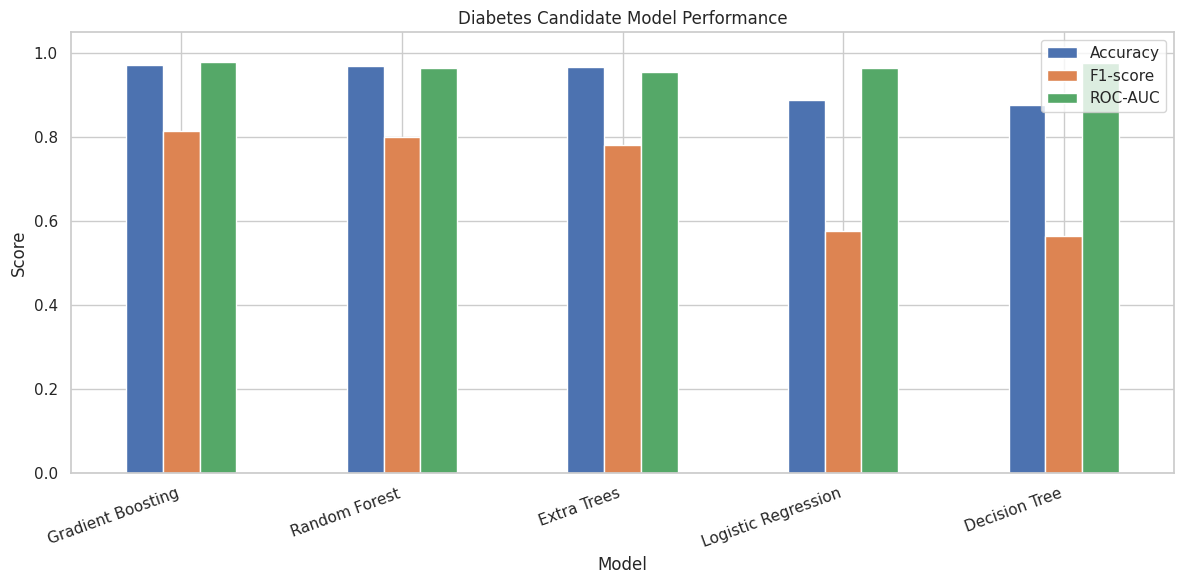

In [19]:
comparison_df.set_index("Model")[["Accuracy", "F1-score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(12, 6)
)
plt.title("Diabetes Candidate Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "candidate_model_performance.png", dpi=300, bbox_inches="tight")
plt.show()

# Hyperparameter tuning

## 17. Tune the Random Forest

In [20]:
rf_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=SEED,
        class_weight="balanced",
        n_jobs=-1
    ))
])

parameter_grid = {
    "classifier__n_estimators": [120, 200],
    "classifier__max_depth": [None, 12, 20],
    "classifier__min_samples_split": [2, 10],
    "classifier__min_samples_leaf": [1, 4],
    "classifier__max_features": ["sqrt", 0.7]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=parameter_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best cross-validation F1:", grid_search.best_score_)
print("Best hyperparameters:")
print(grid_search.best_params_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best cross-validation F1: 0.7931483667033019
Best hyperparameters:
{'classifier__max_depth': None, 'classifier__max_features': 0.7, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}


## 18. Hyperparameter-search results

The graph displays the strongest configurations by cross-validation F1-score.

,Configuration,mean_train_score,mean_test_score,std_test_score,params
9,RF 1,0.996316,0.793148,0.008131,"{'classifier__max_depth': None, 'classifier__m..."
8,RF 2,0.996315,0.792962,0.007486,"{'classifier__max_depth': None, 'classifier__m..."
1,RF 3,0.996316,0.792088,0.006499,"{'classifier__max_depth': None, 'classifier__m..."
0,RF 4,0.996398,0.790788,0.007133,"{'classifier__max_depth': None, 'classifier__m..."
33,RF 5,0.989766,0.785702,0.007285,"{'classifier__max_depth': 20, 'classifier__max..."
32,RF 6,0.988687,0.783871,0.007726,"{'classifier__max_depth': 20, 'classifier__max..."
41,RF 7,0.986813,0.783588,0.008105,"{'classifier__max_depth': 20, 'classifier__max..."
40,RF 8,0.986154,0.782361,0.007212,"{'classifier__max_depth': 20, 'classifier__max..."
11,RF 9,0.969104,0.778802,0.004478,"{'classifier__max_depth': None, 'classifier__m..."
10,RF 10,0.967586,0.778527,0.004779,"{'classifier__max_depth': None, 'classifier__m..."


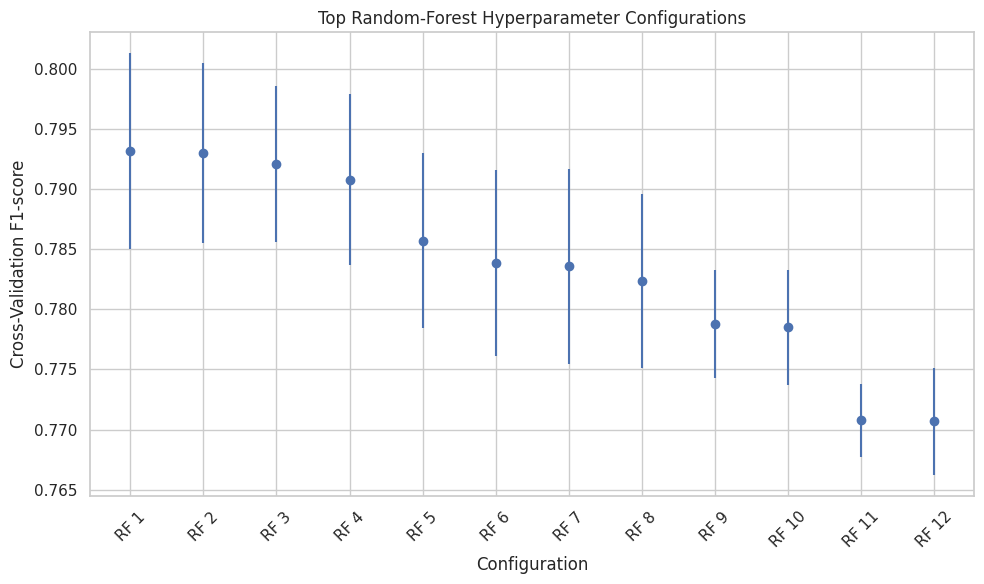

In [21]:
cv_results = pd.DataFrame(grid_search.cv_results_)
top_cv = cv_results.nlargest(12, "mean_test_score").copy()
top_cv["Configuration"] = [
    f"RF {i+1}" for i in range(len(top_cv))
]

display(top_cv[[
    "Configuration",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "params"
]])

plt.figure(figsize=(10, 6))
plt.errorbar(
    top_cv["Configuration"],
    top_cv["mean_test_score"],
    yerr=top_cv["std_test_score"],
    marker="o",
    linestyle=""
)
plt.title("Top Random-Forest Hyperparameter Configurations")
plt.ylabel("Cross-Validation F1-score")
plt.xlabel("Configuration")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "hyperparameter_search_results.png", dpi=300, bbox_inches="tight")
plt.show()

cv_results.to_csv(OUTPUT_DIR / "random_forest_grid_search_results.csv", index=False)

# Final model selection

## 19. Compare the tuned Random Forest with the strongest candidate

The final model is selected primarily by validation F1-score and ROC-AUC.

In [22]:
tuned_rf = grid_search.best_estimator_
rf_val_pred = tuned_rf.predict(X_val)
rf_val_prob = tuned_rf.predict_proba(X_val)[:, 1]

tuned_row = {
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_val, rf_val_pred),
    "Precision": precision_score(y_val, rf_val_pred, zero_division=0),
    "Recall": recall_score(y_val, rf_val_pred, zero_division=0),
    "F1-score": f1_score(y_val, rf_val_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_val, rf_val_prob),
    "Average Precision": average_precision_score(y_val, rf_val_prob)
}

display(pd.DataFrame([tuned_row]))

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Average Precision
0,Tuned Random Forest,0.970467,0.937895,0.698824,0.800899,0.967832,0.86327


## 20. Refit the selected pipeline on training plus validation data

After model selection, the selected Random Forest is trained on 85% of the dataset. The untouched 15% test set is used once for final evaluation.

In [23]:
X_train_final = pd.concat([X_train, X_val], ignore_index=True)
y_train_final = pd.concat([y_train, y_val], ignore_index=True)

best_params = {
    key.replace("classifier__", ""): value
    for key, value in grid_search.best_params_.items()
}

final_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", RandomForestClassifier(
        **best_params,
        random_state=SEED,
        class_weight="balanced",
        n_jobs=-1
    ))
])

final_model.fit(X_train_final, y_train_final)
print("Final model fitted.")

Final model fitted.


# Final test evaluation

## 21. Calculate accuracy and all major classification metrics

In [24]:
test_prediction = final_model.predict(X_test)
test_probability = final_model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, test_prediction),
    "Precision": precision_score(y_test, test_prediction, zero_division=0),
    "Recall": recall_score(y_test, test_prediction, zero_division=0),
    "F1-score": f1_score(y_test, test_prediction, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_probability),
    "Average Precision": average_precision_score(y_test, test_probability)
}

metrics_df = pd.DataFrame({
    "Metric": metrics.keys(),
    "Score": metrics.values()
})
metrics_df["Percentage"] = metrics_df["Score"] * 100
display(metrics_df.round(4))
metrics_df.to_csv(OUTPUT_DIR / "diabetes_evaluation_metrics.csv", index=False)

,Metric,Score,Percentage
0,Accuracy,0.9693,96.9333
1,Precision,0.9493,94.9283
2,Recall,0.6753,67.5294
3,F1-score,0.7892,78.9184
4,ROC-AUC,0.9659,96.5933
5,Average Precision,0.8564,85.6351


## 22. Accuracy testing interpretation

Accuracy measures all correct predictions, but the dataset is imbalanced. Recall measures how many diabetic records were detected. Precision measures how many predicted diabetic cases were actually diabetic. F1 balances both.

In [25]:
report = classification_report(
    y_test,
    test_prediction,
    target_names=["Non-diabetic", "Diabetic"],
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report).transpose()
display(report_df)
report_df.to_csv(OUTPUT_DIR / "diabetes_classification_report.csv")

,precision,recall,f1-score,support
Non-diabetic,0.970624,0.996648,0.983464,13725.000000
Diabetic,0.949283,0.675294,0.789184,1275.000000
accuracy,0.969333,0.969333,0.969333,0.969333
macro avg,0.959954,0.835971,0.886324,15000.000000
weighted avg,0.968810,0.969333,0.966950,15000.000000


## 23. Confusion matrix

- True negatives: correctly predicted non-diabetic records.
- False positives: non-diabetic records predicted as diabetic.
- False negatives: diabetic records missed by the model.
- True positives: correctly detected diabetic records.

In a screening application, false negatives deserve particular attention.

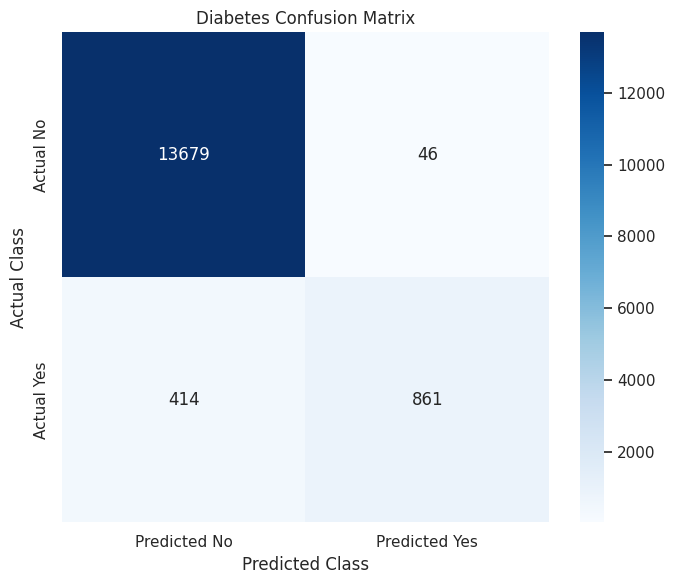

In [26]:
cm = confusion_matrix(y_test, test_prediction)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No", "Predicted Yes"],
    yticklabels=["Actual No", "Actual Yes"]
)
plt.title("Diabetes Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "diabetes_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 24. ROC curve

The ROC curve shows sensitivity against the false-positive rate across thresholds. ROC-AUC summarizes discrimination; a value near 1 indicates strong separation.

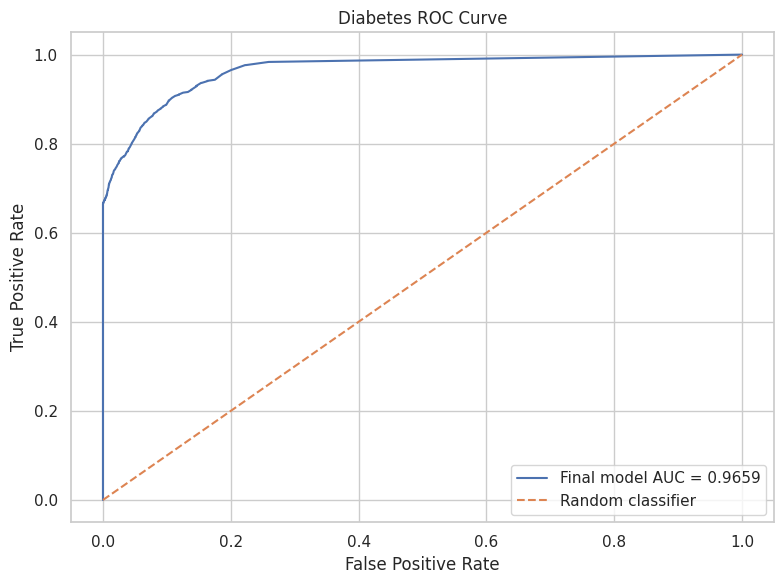

In [27]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_probability)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Final model AUC = {metrics['ROC-AUC']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("Diabetes ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "diabetes_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 25. Precision-recall curve

This curve is particularly informative for imbalanced data because it focuses on the positive diabetic class.

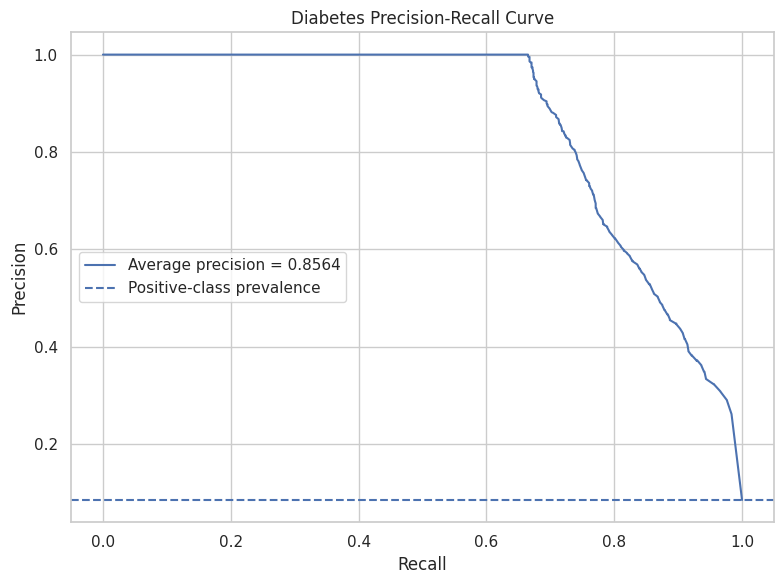

In [28]:
precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test, test_probability
)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_values,
    precision_values,
    label=f"Average precision = {metrics['Average Precision']:.4f}"
)
plt.axhline(y=y_test.mean(), linestyle="--", label="Positive-class prevalence")
plt.title("Diabetes Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "diabetes_precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 26. Actual versus predicted class graph

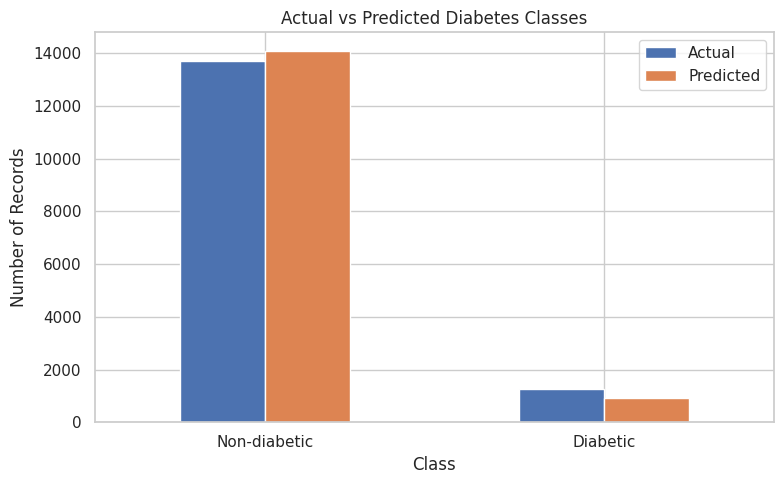

In [29]:
comparison_counts = pd.DataFrame({
    "Class": ["Non-diabetic", "Diabetic"],
    "Actual": [(y_test == 0).sum(), (y_test == 1).sum()],
    "Predicted": [(test_prediction == 0).sum(), (test_prediction == 1).sum()]
}).set_index("Class")

comparison_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Actual vs Predicted Diabetes Classes")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

# Feature importance and confidence

## 27. Feature importance

Random Forest importance shows which transformed inputs contributed most to split decisions. It does not establish medical causality.

,Feature,Importance
13,num__HbA1c_level,4.006307e-01
14,num__blood_glucose_level,2.876814e-01
9,num__age,1.511437e-01
12,num__bmi,1.042336e-01
10,num__hypertension,9.190786e-03
3,cat__smoking_history_No Info,6.519930e-03
7,cat__smoking_history_never,6.424610e-03
0,cat__gender_Female,5.487095e-03
1,cat__gender_Male,5.406730e-03
11,num__heart_disease,5.187149e-03


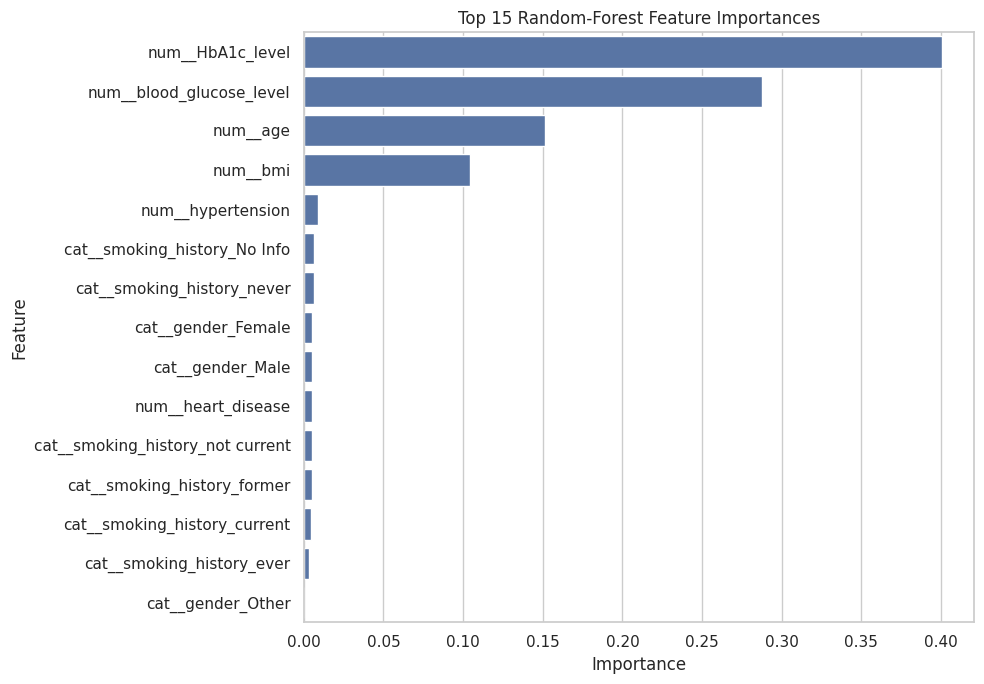

In [30]:
preprocessor = final_model.named_steps["preprocessor"]
classifier = final_model.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": classifier.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Random-Forest Feature Importances")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

importance_df.to_csv(OUTPUT_DIR / "diabetes_feature_importance.csv", index=False)

## 28. Prediction-probability histogram

The histogram shows how confidently the model separates lower and higher diabetes probabilities.

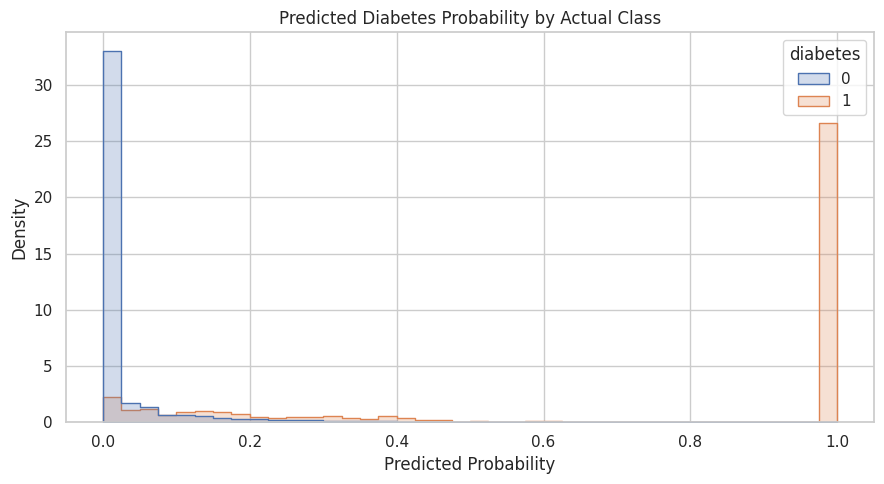

In [31]:
plt.figure(figsize=(9, 5))
sns.histplot(
    x=test_probability,
    hue=y_test.astype(str),
    bins=40,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Predicted Diabetes Probability by Actual Class")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "prediction_probability_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

## 29. Threshold analysis

The default classifier threshold is 0.50. A lower threshold usually detects more diabetic cases but creates more false positives.

,Threshold,Precision,Recall,F1-score,Accuracy
0,0.20,0.651862,0.782745,0.711333,0.946000
1,0.25,0.729872,0.760784,0.745008,0.955733
2,0.30,0.799153,0.739608,0.768228,0.962067
3,0.35,0.849582,0.717647,0.778061,0.965200
4,0.40,0.894153,0.695686,0.782532,0.967133
5,0.45,0.921610,0.682353,0.784137,0.968067
6,0.50,0.947311,0.676863,0.789570,0.969333
7,0.55,0.963004,0.673725,0.792801,0.970067
8,0.60,0.977143,0.670588,0.795349,0.970667
9,0.65,0.991841,0.667451,0.797937,0.971267


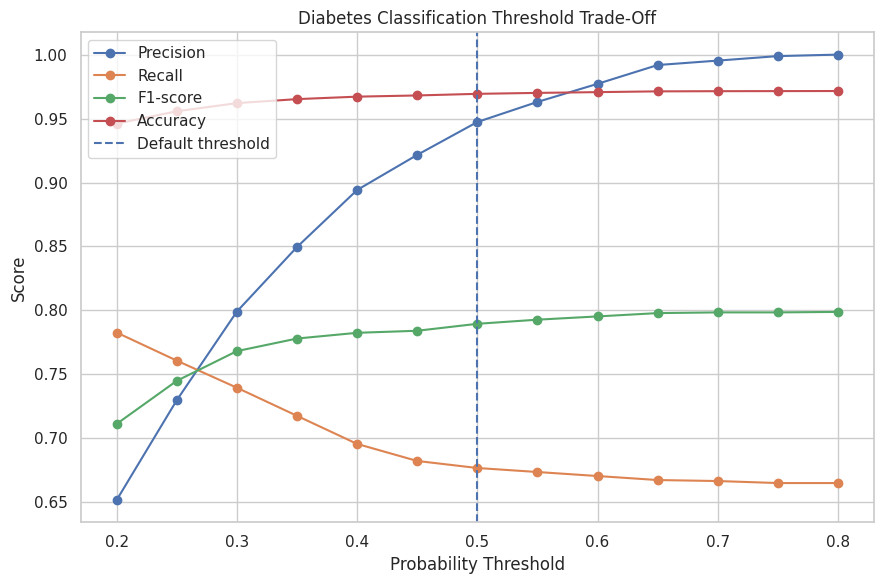

In [32]:
threshold_rows = []

for threshold in np.arange(0.20, 0.81, 0.05):
    threshold_prediction = (test_probability >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": round(float(threshold), 2),
        "Precision": precision_score(y_test, threshold_prediction, zero_division=0),
        "Recall": recall_score(y_test, threshold_prediction, zero_division=0),
        "F1-score": f1_score(y_test, threshold_prediction, zero_division=0),
        "Accuracy": accuracy_score(y_test, threshold_prediction)
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
threshold_df.to_csv(OUTPUT_DIR / "diabetes_threshold_analysis.csv", index=False)

plt.figure(figsize=(9, 6))
for metric in ["Precision", "Recall", "F1-score", "Accuracy"]:
    plt.plot(threshold_df["Threshold"], threshold_df[metric], marker="o", label=metric)
plt.axvline(0.50, linestyle="--", label="Default threshold")
plt.title("Diabetes Classification Threshold Trade-Off")
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "threshold_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

# Response time and prediction records

## 30. Measure prediction response time

,Metric,Value
0,Queries,500.000000
1,Mean (ms),39.585604
2,Median (ms),36.958697
3,Minimum (ms),26.517096
4,Maximum (ms),51.769060
5,95th percentile (ms),47.980844


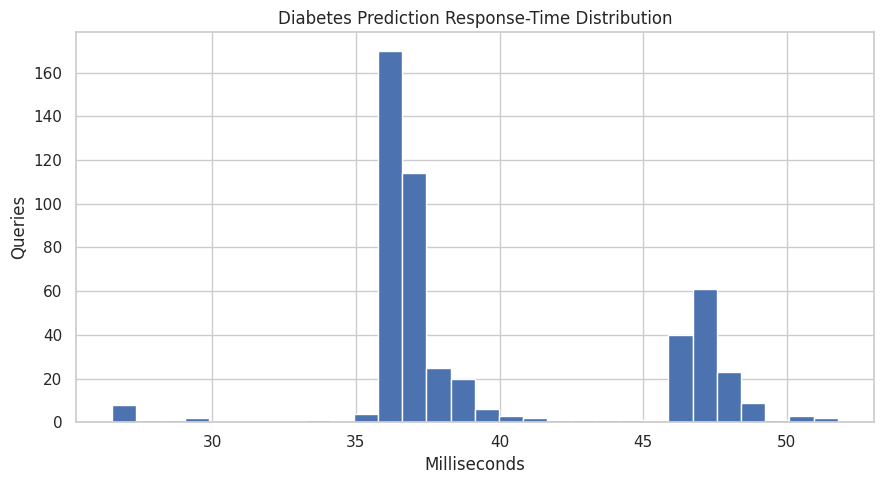

In [33]:
sample_inputs = X_test.sample(min(500, len(X_test)), random_state=SEED)
response_times = []

_ = final_model.predict_proba(sample_inputs.iloc[[0]])

for i in range(len(sample_inputs)):
    start = time.perf_counter()
    _ = final_model.predict_proba(sample_inputs.iloc[[i]])
    response_times.append((time.perf_counter() - start) * 1000)

response_summary = pd.DataFrame({
    "Metric": ["Queries", "Mean (ms)", "Median (ms)", "Minimum (ms)", "Maximum (ms)", "95th percentile (ms)"],
    "Value": [
        len(response_times),
        np.mean(response_times),
        np.median(response_times),
        np.min(response_times),
        np.max(response_times),
        np.percentile(response_times, 95)
    ]
})
display(response_summary)
response_summary.to_csv(OUTPUT_DIR / "diabetes_response_time_summary.csv", index=False)

plt.figure(figsize=(9, 5))
plt.hist(response_times, bins=30)
plt.title("Diabetes Prediction Response-Time Distribution")
plt.xlabel("Milliseconds")
plt.ylabel("Queries")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "diabetes_response_time_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

## 31. Save detailed prediction results

In [34]:
prediction_results = X_test.reset_index(drop=True).copy()
prediction_results["actual_diabetes"] = y_test.reset_index(drop=True)
prediction_results["predicted_diabetes"] = test_prediction
prediction_results["predicted_probability"] = test_probability
prediction_results["correct_prediction"] = (
    prediction_results["actual_diabetes"] ==
    prediction_results["predicted_diabetes"]
)
display(prediction_results.head())
prediction_results.to_csv(OUTPUT_DIR / "diabetes_prediction_results.csv", index=False)

,gender,smoking_history,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,actual_diabetes,predicted_diabetes,predicted_probability,correct_prediction
0,Male,No Info,46.0,0,0,29.06,6.0,155,0,0,0.085,True
1,Female,never,29.0,0,0,24.15,4.0,145,0,0,0.000,True
2,Male,never,30.0,0,0,31.07,3.5,145,0,0,0.000,True
3,Female,ever,39.0,0,0,22.40,5.7,200,0,0,0.005,True
4,Female,No Info,12.0,0,0,32.02,6.5,126,0,0,0.005,True


## 32. Save `diabetes_model.pkl`


In [35]:
MODEL_PATH = OUTPUT_DIR / "diabetes_model.pkl"
joblib.dump(final_model, MODEL_PATH)

reloaded_model = joblib.load(MODEL_PATH)
verification_predictions = reloaded_model.predict(X_test.head(10))

assert np.array_equal(
    verification_predictions,
    final_model.predict(X_test.head(10))
)

print("Saved and verified:", MODEL_PATH)

Saved and verified: /content/izi_diabetes_outputs/diabetes_model.pkl


## 33. Test the exact FastAPI input structure

In [36]:
example_api_input = pd.DataFrame([{
    "gender": "Female",
    "age": 55.0,
    "hypertension": 1,
    "heart_disease": 0,
    "smoking_history": "never",
    "bmi": 31.5,
    "HbA1c_level": 6.5,
    "blood_glucose_level": 160.0
}])

example_prediction = int(reloaded_model.predict(example_api_input)[0])
example_probability = float(
    reloaded_model.predict_proba(example_api_input)[0][1]
)

print({
    "prediction": example_prediction,
    "probability": example_probability
})

{'prediction': 0, 'probability': 0.12}


## 34. Save model metadata

In [37]:
model_information = {
    "project": "IZI Health Diabetes Prediction",
    "target": TARGET,
    "features": FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "model_type": "RandomForestClassifier inside sklearn Pipeline",
    "best_hyperparameters": grid_search.best_params_,
    "training_records_final": int(len(X_train_final)),
    "testing_records": int(len(X_test)),
    "metrics": {k: float(v) for k, v in metrics.items()},
    "positive_class_prevalence": float(y.mean()),
    "default_probability_threshold": 0.5
}

with open(OUTPUT_DIR / "diabetes_model_information.json", "w") as f:
    json.dump(model_information, f, indent=4)

print(json.dumps(model_information, indent=2))

{
  "project": "IZI Health Diabetes Prediction",
  "target": "diabetes",
  "features": [
    "gender",
    "smoking_history",
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
  ],
  "categorical_features": [
    "gender",
    "smoking_history"
  ],
  "numeric_features": [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
  ],
  "model_type": "RandomForestClassifier inside sklearn Pipeline",
  "best_hyperparameters": {
    "classifier__max_depth": null,
    "classifier__max_features": 0.7,
    "classifier__min_samples_leaf": 1,
    "classifier__min_samples_split": 2,
    "classifier__n_estimators": 200
  },
  "training_records_final": 85000,
  "testing_records": 15000,
  "metrics": {
    "Accuracy": 0.9693333333333334,
    "Precision": 0.9492833517089305,
    "Recall": 0.6752941176470588,
    "F1-score": 0.7891842346471127,
    "ROC-AUC": 0.9659330404657308,
    "Average 

## 35. Package and download outputs


In [38]:
PACKAGE_BASE = "/content/IZI_Health_Diabetes_Colab_Outputs"
shutil.make_archive(PACKAGE_BASE, "zip", root_dir=OUTPUT_DIR)
files.download(PACKAGE_BASE + ".zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>